<a href="https://colab.research.google.com/github/joaomadeir4/joaomadeir4/blob/main/Regress%C3%A3o_Linear_Simples_Gols_Esperados_vs_Gols_Reais_Brasileir%C3%A3o_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Atividade: Análise de Regressão Linear Simples**
##### **Aluno**: 2386101573 - João Paulo Alves Madeira


### **Objetivo**
Esta atividade explora a técnica de **Regressão Linear Simples** para compreender como o modelo funciona na prática. O objetivo é aplicar o algoritmo a um conjunto de dados reais e analisar seus resultados, seguindo as etapas de importação, exploração visual e modelagem.

### **Fonte dos Dados** *(Kaggle)*
Para esta análise, foi escolhido o dataset "Brasileirão - Player Stats - 2024", disponível publicamente na plataforma Kaggle e mantido por Eduardo Palmieri.

Link: https://www.kaggle.com/datasets/eduardopalmieri/brasileiro-player-stats-2024

### **Definição do Problema**
A análise irá focar na relação entre duas variáveis numéricas deste dataset para aplicar a Regressão Linear Simples:

*   Variável Independente (X): xG (Gols Esperados)
*   Variável Dependente (y): Gols (Gols Reais)

A hipótese é que existe uma relação linear positiva: quanto maior o xG de um jogador, maior será o número de Gols reais marcados.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("eduardopalmieri/brasileiro-player-stats-2024")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brasileiro-player-stats-2024' dataset.
Path to dataset files: /kaggle/input/brasileiro-player-stats-2024


# **Item 1: Importação e Exploração Inicial dos Dados**
Iniciamos a análise prática importando as bibliotecas necessárias e carregando o arquivo database.csv *(previamente baixado do Kaggle)* para um DataFrame do pandas.

O primeiro passo é inspecionar todos os nomes das colunas para identificar os nomes exatos de nossas variáveis de interesse (xG e Gols).

Em seguida, filtraremos o DataFrame para conter apenas essas duas colunas. Também faremos uma limpeza de dados essencial, removendo quaisquer linhas que contenham valores nulos (NaN), para garantir que o modelo de regressão receba dados válidos.

Finalmente, exibiremos as primeiras linhas (.head()) e as estatísticas descritivas (.describe()) do nosso conjunto de dados limpo para a primeira análise.

In [ ]:
import pandas as pd
import numpy as np
import os

file_path = os.path.join(path, 'database.csv')
df_completo = pd.read_csv(file_path)

print("--- Nomes das Colunas no CSV ---")
print(df_completo.columns.to_list())
print("---------------------------------")

colunas_interesse = ['xG', 'Gols'] #xG são gols esperados | Gols são gols feitos
df = df_completo[colunas_interesse].copy()
df = df.dropna(subset=colunas_interesse)

print("\n--- Primeiras Linhas do Dataset ---")
print(df.head())

print("\n--- Estatísticas Descritivas ---")
print(df.describe())

--- Nomes das Colunas no CSV ---
['Jogador', 'Time', '#', 'Nação', 'Pos.', 'Idade', 'Min.', 'Gols', 'Assis.', 'PB', 'PT', 'TC', 'CaG', 'CrtsA', 'CrtV', 'Contatos', 'Div', 'Crts', 'Bloqueios', 'xG', 'npxG', 'xAG', 'SCA', 'GCA', 'Cmp', 'Att', 'Cmp%', 'PrgP', 'Conduções', 'PrgC', 'Tent', 'Suc', 'Data']
---------------------------------

--- Primeiras Linhas do Dataset ---
    xG  Gols
0  0.0     0
1  0.0     0
2  0.5     1
3  0.0     0
4  0.0     0

--- Estatísticas Descritivas ---
                 xG          Gols
count  11681.000000  11681.000000
mean       0.074822      0.075935
std        0.178805      0.281210
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        0.100000      0.000000
max        1.700000      3.000000


# **Item 2: Visualização Exploratória**
Após a exploração estatística (Item 1), onde vimos que as médias de xG e Gols são muito próximas, o próximo passo é a exploração visual.

Vamos criar um gráfico de dispersão (scatter plot) usando as bibliotecas matplotlib e seaborn. Este gráfico plotará nossa variável independente (xG) no eixo X e nossa variável dependente (Gols) no eixo Y.

O objetivo é analisar visualmente o padrão formado pelos pontos. Se a hipótese estiver correta, esperamos observar uma relação linear positiva, onde os pontos seguem uma tendência de subida **(à medida que o xG aumenta, os Gols também aumentam).**

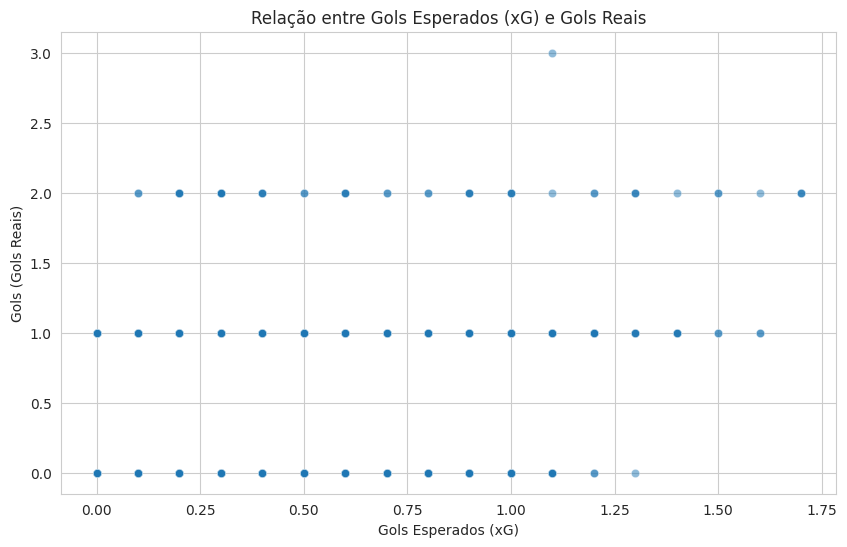

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='xG', y='Gols', alpha=0.5)

plt.title('Relação entre Gols Esperados (xG) e Gols Reais')
plt.xlabel('Gols Esperados (xG)')
plt.ylabel('Gols (Gols Reais)')

plt.show()

# **Item 3: Treinamento do Modelo e Interpretação**
No Item 2, o gráfico nos mostrou que xG e Gols parecem ter uma ligação forte. Agora, vamos usar o scikit-learn (como o professor pediu) para colocar essa ligação em números.

Agora vamos treinar o modelo de Regressão Linear.

O Código vai:
1. Separar os dados em X (nossa coluna xG) e y (nossa coluna Gols).
2. Criar o modelo de Regressão Linear.
3. Treinar o modelo (usando o .fit()) com nossos dados.
4. Pegar e imprimir os números-chave que o modelo encontrou: o Intercepto (onde a linha começa) e o Coeficiente (a inclinação da linha).
5. Desenhar um gráfico final com os nossos dados e a linha de regressão (em vermelho) por cima, para ver como ficou o ajuste.


--- Resultados do Modelo de Regressão ---
Intercepto (Beta 0): 0.0076
Coeficiente (Beta 1) de xG: 0.9138


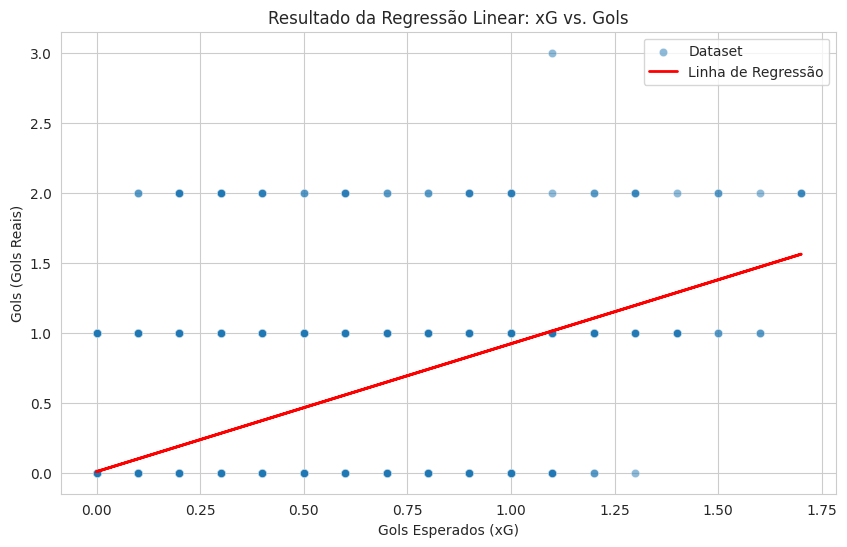

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['xG']]  # Variável independente
y = df['Gols']  # Variável dependente

model = LinearRegression()
model.fit(X, y)

intercepto = model.intercept_
coeficiente = model.coef_[0]

print("--- Resultados do Modelo de Regressão ---")
print(f"Intercepto (Beta 0): {intercepto:.4f}")
print(f"Coeficiente (Beta 1) de xG: {coeficiente:.4f}")

y_pred = model.predict(X)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='xG', y='Gols', alpha=0.5, label='Dataset')

plt.plot(X, y_pred, color='red', linewidth=2, label='Linha de Regressão')

plt.title('Resultado da Regressão Linear: xG vs. Gols')
plt.xlabel('Gols Esperados (xG)')
plt.ylabel('Gols (Gols Reais)')
plt.legend()
plt.show()

# **Item 3: Interpretação dos Valores Obtidos**
O modelo nos deu os seguintes valores (baseado no seu output):

* **Intercepto (Beta 0):** 0.0076
* **Coeficiente (Beta 1) de xG:** 0.9138


1. **Interpretando o Intercepto (0.0076):** O valor é quase zero. Isso significa que se um jogador tem 0 xG, o modelo prevê 0 gols.

2. **Interpretando o Coeficiente (0.9138):** Este é o resultado principal. Ele diz que para cada 1.0 ponto de xG (Gols Esperados), o modelo prevê um aumento de 0.9138 em Gols (Gols Reais).



**Conclusão da Atividade:** A Regressão Linear validou nossa hipótese. Existe uma forte relação positiva entre xG e Gols. O valor do coeficiente (0.9138) ser tão próximo de 1.0 mostra que o xG é um ótimo preditor estatístico para os gols que realmente acontecem.

In [ ]:
##Convertendo em HTML
!jupyter nbconvert --execute --to html "/content/Regressão_Linear_Simples_Gols_Esperados_vs_Gols_Reais_Brasileirão_2024.ipynb"

[NbConvertApp] Converting notebook /content/Regressão_Linear_Simples_Gols_Esperados_vs_Gols_Reais_Brasileirão_2024.ipynb to html
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Wr